# Interactive Hückel Theory: From Molecular Graphs to Molecular Orbitals

Welcome!

This notebook is the hands on companion to the Bonds & Nodes article on Hückel molecular orbital theory.

The goal here is to walk through, step by step, how a molecule turns into a matrix, and how that matrix reveals the molecule's electronic structure.

You do not need a background in quantum chemistry to follow  (just like myself!). You do need basic chemistry (atoms, bonds, aromatic rings) and a willingness to learn a bit of Python and linear algebra as we go. If a term feels intimidating the first time you see it, keep reading. I will unpack it with plain language before we ever touch the equation.

Every section below follows the same rhythm:

1. A short explanation of *why* we are doing something
2. Code that does it
3. A small challenge inviting you to poke at it yourself

To fully live up to this notebook (and your) potential, try not to read passively. Feel free to change numbers, break things and see what happens.

## Section 1: What are we trying to compute?

Hückel theory is one of the oldest tricks in quantum chemistry, and it is also one of the clearest. It takes a molecule and turns it into a matrix called the **Hamiltonian**, and then it asks a very specific question of that matrix: *what are your eigenvalues and eigenvectors?*

The eigenvalues turn out to be the energies of the molecular orbitals. The eigenvectors tell you how the electrons are distributed across the atoms in each orbital. That is genuinely the whole idea. No wavefunctions integrated numerically, no exchange correlation functionals, just a matrix built from the molecule's connectivity and a bit of linear algebra.

Here is the pipeline we will implement from scratch in this notebook:

```
Molecule
    |
Molecular graph
    |
Adjacency matrix
    |
Hückel Hamiltonian
    |
Eigenvalues
    |
Eigenvectors
    |
Electronic structure
```

Each arrow in that diagram is one small, understandable step. By the end of the notebook you will have built every one of them yourself, and you will be able to point at any number in the final result and explain exactly where it came from.

## Section 2: Installing and importing libraries

We only need three tools for this whole notebook.

**RDKit** is a cheminformatics library. It reads chemical structures written as SMILES strings, figures out which atoms are bonded to which, and can draw the resulting molecule. We will use it to turn a line of text into a molecular graph.

**NumPy** gives us fast, reliable linear algebra. Once we have built the Hamiltonian matrix, NumPy is what actually solves the eigenvalue problem for us.

**Matplotlib** is for visualization. We will use it to draw heatmaps of matrices and plot molecular orbital energy levels.

If you are running this in Google Colab, RDKit is not preinstalled, so the first line below installs it. If you are running this locally with RDKit already available (for example through conda), that line will simply do nothing harmful, it will just confirm the package is present.

In [1]:
# Install RDKit if it is not already available (this is mainly needed on Google Colab)
try:
    import rdkit
except ImportError:
    %pip install rdkit

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D

# A small aesthetic choice: we will keep our plots minimal and consistent
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

print("Libraries loaded. RDKit version:", rdkit.__version__)

Libraries loaded. RDKit version: 2026.03.3


## Section 3: Reading a molecule

Chemists need a way to write down molecular structures as plain text so that software can read them. The most common format for this is **SMILES** (Simplified Molecular Input Line Entry System).

A SMILES string encodes atoms and bonds using a small set of rules. For example, benzene, the six carbon aromatic ring you probably drew a hundred times in undergrad, is written as:

```
c1ccccc1
```

The lowercase `c` tells RDKit that these carbons are aromatic. The `1 ... 1` pair marks where the ring closes back on itself.

Once RDKit parses a SMILES string, it builds an internal molecular graph. Every atom becomes a **node**, and every bond becomes an **edge** connecting two nodes. This is exactly the graph structure we need for Hückel theory, since Hückel theory only cares about which atoms are connected, not about their 3D coordinates.

Let's parse benzene and draw it.

Number of atoms: 6
Number of bonds: 6


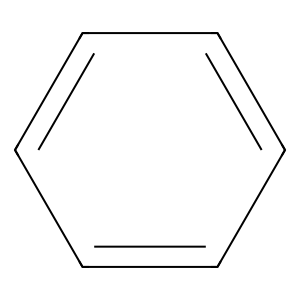

In [3]:
# Benzene, written as a SMILES string
benzene_smiles = "c1ccccc1"

# Ask RDKit to parse the SMILES string into a molecule object
benzene = Chem.MolFromSmiles(benzene_smiles)

# Compute 2D coordinates purely so we have something sensible to draw
AllChem.Compute2DCoords(benzene)

print("Number of atoms:", benzene.GetNumAtoms())
print("Number of bonds:", benzene.GetNumBonds())

Draw.MolToImage(benzene, size=(300, 300))

Take a moment to look at the atom and bond counts. Six atoms, six bonds, which matches what you would expect for a six membered ring where every atom is bonded to exactly two neighbors.

RDKit did the hard work of parsing the string. Every atom in the resulting molecule object is now a node in a graph, and every bond is an edge. That graph is the raw material Hückel theory works with. We have not touched any quantum mechanics yet, we have just gotten our molecule into a form that a computer, and a matrix, can work with.

**Try it yourself:** Replace the SMILES string above with another aromatic molecule. Naphthalene is `c1ccc2ccccc2c1`, and furan is `c1ccoc1`. Does RDKit parse it correctly? How many atoms and bonds does it report, and does that match what you expect by drawing the structure on paper first?

## Section 4: Constructing the adjacency matrix

Now that we have a molecular graph, we need a way to represent "who is connected to whom" as numbers, because linear algebra does not understand pictures of hexagons.

The tool for this is the **adjacency matrix**. For a molecule with N atoms, the adjacency matrix A is an N by N grid of numbers where:

- `A[i][j] = 1` if atom i and atom j are directly bonded
- `A[i][j] = 0` if they are not bonded (including an atom's relationship to itself)

That is the entire definition. No energies, no chemistry yet, just connectivity written as a grid of ones and zeros.

RDKit can hand us this matrix directly, so we do not need to build it by hand from the bond list, although you certainly could.

**Before running the code below, take a guess.** Benzene has six atoms arranged in a ring, where each atom is bonded to exactly two neighbors. Sketch out on paper (or just in your head) what a 6 by 6 adjacency matrix should look like for a ring like that. Where would the 1s fall relative to the diagonal?

In [4]:
from rdkit.Chem import rdmolops

# RDKit can compute the adjacency matrix for us directly from the molecule graph
adjacency_benzene = rdmolops.GetAdjacencyMatrix(benzene)

print("Adjacency matrix for benzene:\n")
print(adjacency_benzene)

Adjacency matrix for benzene:

[[0 1 0 0 0 1]
 [1 0 1 0 0 0]
 [0 1 0 1 0 0]
 [0 0 1 0 1 0]
 [0 0 0 1 0 1]
 [1 0 0 0 1 0]]


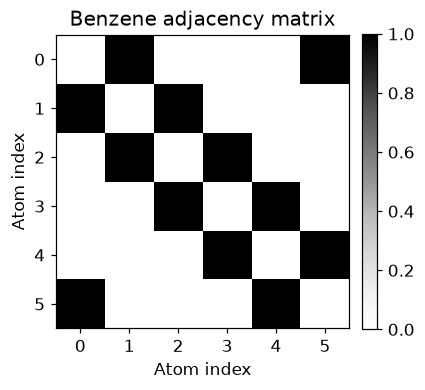

In [5]:
# A heatmap makes the pattern of connections much easier to see than raw numbers
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(adjacency_benzene, cmap="Greys")
ax.set_title("Benzene adjacency matrix")
ax.set_xlabel("Atom index")
ax.set_ylabel("Atom index")
ax.set_xticks(range(6))
ax.set_yticks(range(6))
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Notice the pattern. Every row has exactly two 1s, because every carbon in benzene is bonded to exactly two neighboring carbons. The diagonal is entirely zero, because we do not count an atom as bonded to itself. And the matrix is symmetric, `A[i][j]` always equals `A[j][i]`, because a bond between atom i and atom j is the same bond whether you look at it from i's side or from j's side.

This symmetry will matter later. It is one of the reasons the Hamiltonian we build from this matrix has real eigenvalues, which is exactly what we need for the eigenvalues to represent physical energies.

**Try it yourself:** Did your guess from before match the matrix RDKit produced? If not, where did your intuition go wrong? Try naphthalene's adjacency matrix next, it has ten atoms, and see if you can spot which atoms are the "junction" carbons shared between the two rings just by looking at the matrix.

## Section 5: Building the Hückel Hamiltonian

The adjacency matrix tells us which atoms are connected. The **Hamiltonian** tells us about energy. Building it from the adjacency matrix is where Hückel theory actually becomes a piece of quantum chemistry rather than just graph bookkeeping.

Hückel theory makes two big simplifying assumptions, and naming them clearly is important because most of the theory's strengths and weaknesses trace back to these two numbers:

**The Coulomb integral, alpha (α).** This is the energy of an electron sitting on a single atom, ignoring all of its neighbors. Think of it as a baseline energy level, the energy an electron would have if that atom existed all on its own. Every diagonal entry of the Hamiltonian starts out as alpha.

**The resonance integral, beta (β).** This describes how strongly an electron can hop between two bonded atoms. It is what allows electrons to delocalize across a molecule instead of staying stuck on one atom. Beta is always negative, because delocalization lowers a molecule's energy, and every off diagonal entry corresponding to a bonded pair gets set to beta.

In equation form, for a plain hydrocarbon where every atom is carbon:

$$
H_{ii} = \alpha \qquad H_{ij} = \begin{cases} \beta & \text{if atoms } i \text{ and } j \text{ are bonded} \\ 0 & \text{otherwise} \end{cases}
$$

Rather than hiding this inside a function right away, let's build it by hand for benzene first, one piece at a time, so every entry is something you placed there deliberately.

In [6]:
# We work in units of beta, so we set alpha = 0 and beta = -1
# This is a very common convention in Hückel theory: energies are reported
# relative to alpha, in multiples of beta
alpha = 0.0
beta = -1.0

n_atoms = benzene.GetNumAtoms()

# Start with an empty matrix full of zeros
H_benzene = np.zeros((n_atoms, n_atoms))

# Step 1: every diagonal entry is alpha
for i in range(n_atoms):
    H_benzene[i, i] = alpha

print("Hamiltonian after filling in the diagonal (alpha values):\n")
print(H_benzene)

Hamiltonian after filling in the diagonal (alpha values):

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


In [7]:
# Step 2: every bonded pair gets beta in both off-diagonal positions
# We reuse the adjacency matrix we already built, since "bonded" is exactly
# what the adjacency matrix encodes
for i in range(n_atoms):
    for j in range(n_atoms):
        if adjacency_benzene[i, j] == 1:
            H_benzene[i, j] = beta

print("Full Hückel Hamiltonian for benzene:\n")
print(H_benzene)

Full Huckel Hamiltonian for benzene:

[[ 0. -1.  0.  0.  0. -1.]
 [-1.  0. -1.  0.  0.  0.]
 [ 0. -1.  0. -1.  0.  0.]
 [ 0.  0. -1.  0. -1.  0.]
 [ 0.  0.  0. -1.  0. -1.]
 [-1.  0.  0.  0. -1.  0.]]


That's it, that is the entire Hamiltonian. Every diagonal entry is alpha (which we set to 0), and every off diagonal entry is either beta (if the two atoms are bonded) or 0 (if they are not). You built this by hand, entry by entry, so there is no mystery left in it.

Now that you understand exactly what this matrix contains, it makes sense to wrap the construction into a reusable function. We do not do this to hide anything, we do it because we will want to repeat this exact process for many different molecules throughout the rest of the notebook, and typing out two nested loops every time would get old fast.

In [8]:
def Hückel_from_smiles(smiles, heteroatom_shifts=None, beta=-1.0):
    """
    Build a Hückel Hamiltonian directly from a SMILES string.

    Parameters
    ----------
    smiles : str
        The SMILES string of the molecule.
    heteroatom_shifts : dict, optional
        A dictionary mapping atom index -> h_X value, used to adjust the
        Coulomb integral for heteroatoms. See Section 8 for what this means.
        Atoms not listed here are treated as plain carbon (alpha = 0).
    beta : float
        The resonance integral, in whatever energy units you prefer.
        We use beta as our unit of energy, so it defaults to -1.0.

    Returns
    -------
    H : np.ndarray
        The Hückel Hamiltonian matrix.
    mol : rdkit.Chem.Mol
        The parsed RDKit molecule, in case you want to draw it or inspect it.
    adjacency : np.ndarray
        The adjacency matrix used to build H.
    """
    if heteroatom_shifts is None:
        heteroatom_shifts = {}

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKit could not parse this SMILES string: {smiles}")

    AllChem.Compute2DCoords(mol)
    adjacency = rdmolops.GetAdjacencyMatrix(mol)
    n = mol.GetNumAtoms()

    H = np.zeros((n, n))

    # Diagonal: alpha, shifted for heteroatoms if requested
    for i in range(n):
        h_x = heteroatom_shifts.get(i, 0.0)
        H[i, i] = 0.0 + h_x * beta   # alpha_X = alpha + h_X * beta, with alpha = 0

    # Off-diagonal: beta wherever atoms are bonded
    for i in range(n):
        for j in range(n):
            if adjacency[i, j] == 1:
                H[i, j] = beta

    return H, mol, adjacency


# Sanity check: rebuilding benzene with the function should match what we did by hand
H_check, _, _ = Hückel_from_smiles("c1ccccc1")
print("Function output matches the hand-built matrix:", np.allclose(H_check, H_benzene))

Function output matches the hand-built matrix: True


**Try it yourself:** Before we used `Hückel_from_smiles`, we built the matrix with two separate loops, one for the diagonal and one for the off-diagonal entries. Try combining them into a single loop that fills in both at once. Does the result change? (It shouldn't, but confirming this yourself is a good way to make sure you really understand what each loop is doing.)

## Section 6: Solving the eigenvalue problem

We now have a Hamiltonian matrix. The next step is the payoff: diagonalizing it.

When we diagonalize the Hamiltonian, we are solving the eigenvalue equation:

$$
H \mathbf{c} = E \mathbf{c}
$$

Here, $E$ is an **eigenvalue** and $\mathbf{c}$ is its corresponding **eigenvector**. In the language of Hückel theory:

**Eigenvalues** are the allowed energies of the molecular orbitals. Each eigenvalue is one molecular orbital's energy, expressed in units of beta relative to alpha.

**Eigenvectors** tell you how much each atom contributes to that particular molecular orbital. A large coefficient on a given atom means a large share of the electron density in that orbital sits on that atom.

Because our Hamiltonian is a real, symmetric matrix (remember, `H[i][j] = H[j][i]`, a direct consequence of the adjacency matrix being symmetric), we can use NumPy's `eigh` function, which is specifically built for symmetric matrices. It is faster and numerically more stable than the general purpose `eig` function, and it guarantees real eigenvalues, exactly what we want since these numbers represent physical energies.

In [9]:
# eigh returns eigenvalues sorted from smallest to largest, along with the
# matching eigenvectors as columns of a matrix
eigenvalues, eigenvectors = np.linalg.eigh(H_benzene)

print("Molecular orbital energies (in units of beta):")
for idx, e in enumerate(eigenvalues):
    print(f"  MO {idx + 1}: E = {e:.3f}")

Molecular orbital energies (in units of beta):
  MO 1: E = -2.000
  MO 2: E = -1.000
  MO 3: E = -1.000
  MO 4: E = 1.000
  MO 5: E = 1.000
  MO 6: E = 2.000


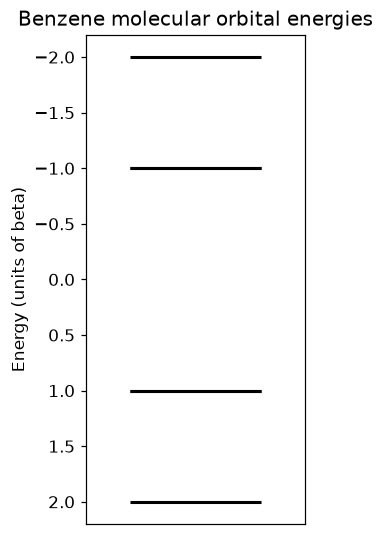

In [10]:
fig, ax = plt.subplots(figsize=(3, 5))

for e in eigenvalues:
    ax.hlines(e, xmin=0.2, xmax=0.8, color="black", linewidth=2)

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_ylabel("Energy (units of beta)")
ax.set_title("Benzene molecular orbital energies")
ax.invert_yaxis()  # lower energy (more negative) is more stable, draw it at the top
plt.tight_layout()
plt.show()

Remember, we set beta to a negative number, so lower (more negative) energy means a more stable orbital. That is why the plot inverts the y axis, so that the most stable orbitals appear near the top, matching how chemists usually draw molecular orbital diagrams.

**Try it yourself:** `eigh` conveniently gives us the eigenvalues already sorted. Try calling `np.linalg.eig` instead (without the `h`) on the same matrix and compare the output. Do you get the same eigenvalues, just possibly in a different order? What happens to the imaginary parts, if any?

## Section 7: Example 1, Benzene

Let's now go through benzene properly as our reference molecule, pulling together everything from the sections above: the adjacency matrix, the Hamiltonian, the energy levels, and the orbital coefficients.

In [11]:
H_benzene, mol_benzene, adj_benzene = Hückel_from_smiles("c1ccccc1")
energies_benzene, coeffs_benzene = np.linalg.eigh(H_benzene)

print("Adjacency matrix:\n", adj_benzene, "\n")
print("Hamiltonian:\n", H_benzene, "\n")
print("Orbital energies (units of beta):", np.round(energies_benzene, 3))

Adjacency matrix:
 [[0 1 0 0 0 1]
 [1 0 1 0 0 0]
 [0 1 0 1 0 0]
 [0 0 1 0 1 0]
 [0 0 0 1 0 1]
 [1 0 0 0 1 0]] 

Hamiltonian:
 [[ 0. -1.  0.  0.  0. -1.]
 [-1.  0. -1.  0.  0.  0.]
 [ 0. -1.  0. -1.  0.  0.]
 [ 0.  0. -1.  0. -1.  0.]
 [ 0.  0.  0. -1.  0. -1.]
 [-1.  0.  0.  0. -1.  0.]] 

Orbital energies (units of beta): [-2. -1. -1.  1.  1.  2.]


In [12]:
# The eigenvector coefficients tell us how each molecular orbital is built
# from the six carbon 2p orbitals. Each column is one molecular orbital.
print("Orbital coefficients (each column is one MO):\n")
print(np.round(coeffs_benzene, 3))

Orbital coefficients (each column is one MO):

[[ 0.408 -0.576  0.045  0.577 -0.    -0.408]
 [ 0.408 -0.327 -0.476 -0.289 -0.5    0.408]
 [ 0.408  0.249 -0.521 -0.289  0.5   -0.408]
 [ 0.408  0.576 -0.045  0.577 -0.     0.408]
 [ 0.408  0.327  0.476 -0.289 -0.5   -0.408]
 [ 0.408 -0.249  0.521 -0.289  0.5    0.408]]


Look closely at the energy list: `[-2, -1, -1, 1, 1, 2]` in units of beta. Notice that the second and third values are identical, and so are the fourth and fifth. This is **degeneracy**, two or more molecular orbitals sharing exactly the same energy.

Why does this happen? Benzene has six fold rotational symmetry, rotating the molecule by 60 degrees maps it perfectly onto itself. Whenever a molecule has this kind of symmetry, certain orbitals are mathematically forced to pair up with identical energies. This is not a coincidence or a numerical accident, it is a direct consequence of the molecule's symmetry, and it is one of the cleanest ways to see group theory show up in a calculation without ever explicitly invoking group theory.

**Try it yourself:** Look at the printed list of six energies. Can you identify which pairs of orbitals are degenerate just from the numbers? Now look at their corresponding eigenvector columns, do degenerate orbitals have any obvious relationship in their coefficients?

## Section 8: Example 2, Pyridine

Pyridine looks almost exactly like benzene, except one CH position in the ring is replaced by a nitrogen atom. Chemically, that single substitution matters a lot, nitrogen is more electronegative than carbon, so it holds onto its electron more tightly.

In Hückel theory, we capture this with a **heteroatom parameter**, usually written $h_X$. It shifts the Coulomb integral for that one atom:

$$
\alpha_X = \alpha + h_X \beta
$$

For pyridine type nitrogen, the commonly tabulated value is $h_N \approx 0.5$. Since beta is negative, this makes the nitrogen's diagonal entry more negative than a plain carbon's, meaning an electron sitting on that nitrogen has lower energy than one sitting on a carbon. That matches the chemical intuition: nitrogen "wants" the electron more.

Notice what does **not** change: the resonance integral beta stays the same for every bond, and the adjacency matrix (the connectivity) is identical to benzene's. Only one diagonal entry of the Hamiltonian shifts. Everything else in the machinery, the eigenvalue problem, the diagonalization, stays exactly as it was.

SMILES for pyridine is `c1ccncc1`, where the lowercase `n` marks the ring nitrogen.

In [13]:
pyridine_smiles = "c1ccncc1"

# Find which atom index in the SMILES string corresponds to the nitrogen,
# since that is the atom whose diagonal entry we need to shift
mol_pyridine_probe = Chem.MolFromSmiles(pyridine_smiles)
nitrogen_index = [atom.GetIdx() for atom in mol_pyridine_probe.GetAtoms()
                   if atom.GetSymbol() == "N"][0]

print("Nitrogen sits at atom index:", nitrogen_index)

h_N = 0.5
H_pyridine, mol_pyridine, adj_pyridine = Hückel_from_smiles(
    pyridine_smiles,
    heteroatom_shifts={nitrogen_index: h_N}
)

print("\nPyridine Hamiltonian (compare the diagonal to benzene's):\n")
print(np.round(H_pyridine, 3))

Nitrogen sits at atom index: 3

Pyridine Hamiltonian (compare the diagonal to benzene's):

[[ 0.  -1.   0.   0.   0.  -1. ]
 [-1.   0.  -1.   0.   0.   0. ]
 [ 0.  -1.   0.  -1.   0.   0. ]
 [ 0.   0.  -1.  -0.5 -1.   0. ]
 [ 0.   0.   0.  -1.   0.  -1. ]
 [-1.   0.   0.   0.  -1.   0. ]]


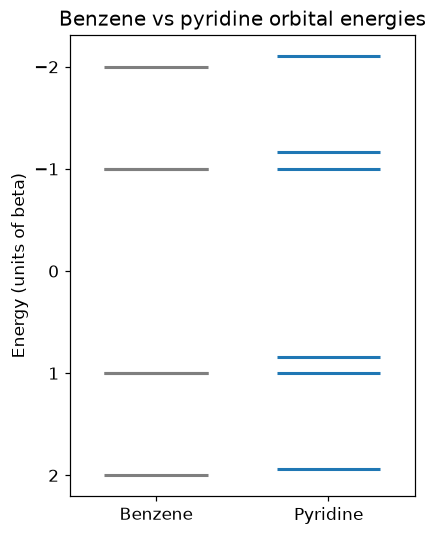

Benzene energies:  [-2. -1. -1.  1.  1.  2.]
Pyridine energies: [-2.107 -1.167 -1.     0.841  1.     1.934]


In [14]:
energies_pyridine, coeffs_pyridine = np.linalg.eigh(H_pyridine)

fig, ax = plt.subplots(figsize=(4, 5))
ax.hlines(energies_benzene, xmin=0.1, xmax=0.4, color="tab:gray", linewidth=2, label="Benzene")
ax.hlines(energies_pyridine, xmin=0.6, xmax=0.9, color="tab:blue", linewidth=2, label="Pyridine")
ax.set_xlim(0, 1)
ax.set_xticks([0.25, 0.75], ["Benzene", "Pyridine"])
ax.set_ylabel("Energy (units of beta)")
ax.set_title("Benzene vs pyridine orbital energies")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Benzene energies: ", np.round(energies_benzene, 3))
print("Pyridine energies:", np.round(energies_pyridine, 3))

Look at what happened to the degenerate pairs. In benzene, orbitals 2 and 3 shared an energy, and so did orbitals 4 and 5. In pyridine, those pairs split apart into distinct energies. Replacing one carbon with nitrogen breaks the six fold rotational symmetry that was responsible for the degeneracy in the first place. The ring is still a hexagon, but it is no longer a symmetric one, so the mathematical reason for those orbitals to match disappears along with the symmetry.

**Try it yourself:** Change `h_N` in the code above to 0.2, then to 0.8, and rerun the comparison plot. How does the size of the diagonal shift affect how far the split orbitals move apart? Is the relationship roughly linear?

## Section 9: Example 3, Pyrimidine

Now let's push this one step further. Pyrimidine has two nitrogen atoms in the ring instead of one. In Hückel terms, this means two diagonal entries of the Hamiltonian get shifted instead of just one, while the adjacency matrix and every off diagonal beta stay exactly as they were for benzene and pyridine.

SMILES for pyrimidine is `c1ccncn1`.

In [15]:
pyrimidine_smiles = "c1ccncn1"

mol_pyrimidine_probe = Chem.MolFromSmiles(pyrimidine_smiles)
nitrogen_indices = [atom.GetIdx() for atom in mol_pyrimidine_probe.GetAtoms()
                     if atom.GetSymbol() == "N"]

print("Nitrogens sit at atom indices:", nitrogen_indices)

shifts = {idx: 0.5 for idx in nitrogen_indices}
H_pyrimidine, mol_pyrimidine, adj_pyrimidine = Hückel_from_smiles(
    pyrimidine_smiles,
    heteroatom_shifts=shifts
)

energies_pyrimidine, coeffs_pyrimidine = np.linalg.eigh(H_pyrimidine)

print("\nPyrimidine Hamiltonian:\n")
print(np.round(H_pyrimidine, 3))

Nitrogens sit at atom indices: [3, 5]

Pyrimidine Hamiltonian:

[[ 0.  -1.   0.   0.   0.  -1. ]
 [-1.   0.  -1.   0.   0.   0. ]
 [ 0.  -1.   0.  -1.   0.   0. ]
 [ 0.   0.  -1.  -0.5 -1.   0. ]
 [ 0.   0.   0.  -1.   0.  -1. ]
 [-1.   0.   0.   0.  -1.  -0.5]]


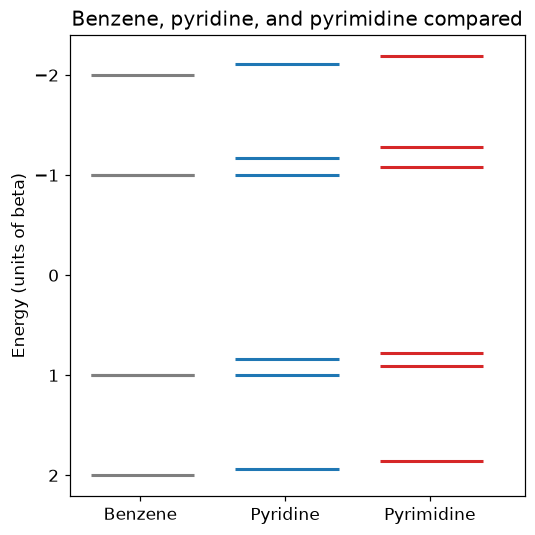

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))
labels = ["Benzene", "Pyridine", "Pyrimidine"]
energy_sets = [energies_benzene, energies_pyridine, energies_pyrimidine]
colors = ["tab:gray", "tab:blue", "tab:red"]

for i, (label, energies, color) in enumerate(zip(labels, energy_sets, colors)):
    x_start = i * 0.35 + 0.05
    ax.hlines(energies, xmin=x_start, xmax=x_start + 0.25, color=color, linewidth=2)

ax.set_xlim(0, 1.1)
ax.set_xticks([0.17, 0.52, 0.87], labels)
ax.set_ylabel("Energy (units of beta)")
ax.set_title("Benzene, pyridine, and pyrimidine compared")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

As we go from benzene, to pyridine, to pyrimidine, we are systematically breaking more and more of the ring's symmetry, and the orbital energies spread further and further apart. With one nitrogen, one degenerate pair split. With two nitrogens (positioned asymmetrically in this particular isomer), the spectrum spreads out even more, and depending on exactly where the two nitrogens sit relative to each other, the remaining symmetry, if any, determines whether any degeneracy survives at all.

**Try it yourself, but predict first:** Before scrolling back up and rerunning anything, think about whether adding a second heteroatom should generally increase or decrease the amount of splitting compared to pyridine's single substitution. Write down your prediction, then check it against the plot. Were you right? Now try a different pyrimidine style SMILES with the nitrogens in different ring positions, does the amount of splitting change?

## Section 10: Example 4, Azulene

Every example so far has changed the electronic structure by swapping atom types (carbon to nitrogen). Azulene gives us a different kind of change entirely: every atom is still carbon, but the molecule is not a single six membered ring. Azulene is a fused bicyclic system, a five membered ring fused to a seven membered ring, sharing one edge between them.

This matters because it shows that Hückel theory is sensitive to **graph topology itself**, not just to which atom sits where. Change the shape of the connectivity graph, even while keeping every atom the same element, and the electronic structure changes.

A five membered ring and a seven membered ring sharing one edge works out to 5 + 7 - 2 = 10 atoms total, since the two shared fusion carbons are only counted once. SMILES for azulene is `c1ccc2ccccc21`.

Number of atoms in azulene: 10


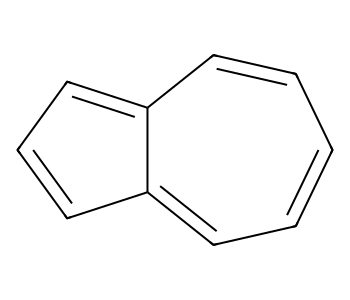

In [18]:
azulene_smiles = "C1=CC=CC=C2C1=CC=C2"

H_azulene, mol_azulene, adj_azulene = Hückel_from_smiles(azulene_smiles)
energies_azulene, coeffs_azulene = np.linalg.eigh(H_azulene)

print("Number of atoms in azulene:", mol_azulene.GetNumAtoms())

AllChem.Compute2DCoords(mol_azulene)
Draw.MolToImage(mol_azulene, size=(350, 300))

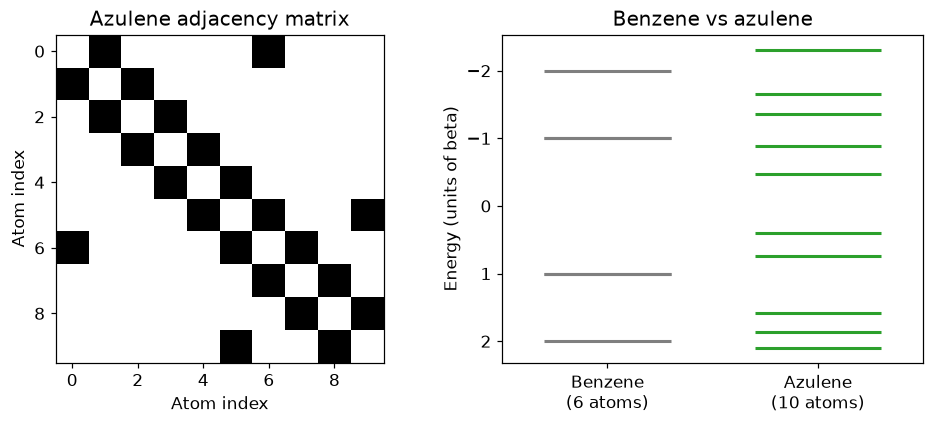

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

im = axes[0].imshow(adj_azulene, cmap="Greys")
axes[0].set_title("Azulene adjacency matrix")
axes[0].set_xlabel("Atom index")
axes[0].set_ylabel("Atom index")

axes[1].hlines(energies_benzene, xmin=0.1, xmax=0.4, color="tab:gray", linewidth=2)
axes[1].hlines(energies_azulene, xmin=0.6, xmax=0.9, color="tab:green", linewidth=2)
axes[1].set_xlim(0, 1)
axes[1].set_xticks([0.25, 0.75], ["Benzene\n(6 atoms)", "Azulene\n(10 atoms)"])
axes[1].set_ylabel("Energy (units of beta)")
axes[1].set_title("Benzene vs azulene")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Azulene's spectrum has ten energy levels instead of six, since it has ten carbons instead of six, but more importantly the pattern of spacing between levels looks nothing like benzene's neatly paired structure. There is no six fold symmetry here to force any degeneracies. The molecule is lower symmetry by construction, a five membered ring fused to a seven membered ring simply does not have the same rotational symmetry a single hexagon has.

This is worth sitting with for a moment: we did not touch a single atom type. Every entry on the diagonal of azulene's Hamiltonian is still alpha (0, in our units). The entire change in the spectrum came purely from which off diagonal entries are beta versus zero, in other words, purely from connectivity.

**Try it yourself:** Look carefully at azulene's adjacency matrix heatmap. Can you find the two atoms that are shared between the five membered and seven membered rings, the fusion carbons? Hint, look for rows with an unusual pattern of connections compared to the rest.

## Section 11: Comparing all molecules

Let's now bring everything together into one summary. A useful pair of numbers for comparing molecules is the **HOMO** (highest occupied molecular orbital) and **LUMO** (lowest unoccupied molecular orbital) energies, along with the gap between them.

For a neutral, closed shell pi system, each molecular orbital holds two electrons, and orbitals fill from lowest to highest energy. So the HOMO is the highest energy orbital that still has electrons in it, and the LUMO is the next orbital up, the first one that is empty. The HOMO-LUMO gap is a rough proxy for how easily a molecule can be excited by light or how reactive it might be, smaller gaps generally mean lower energy electronic transitions.

In [20]:
def summarize(name, smiles, mol, energies, heteroatom_shifts=None):
    n_atoms = mol.GetNumAtoms()
    n_hetero = 0 if heteroatom_shifts is None else len(heteroatom_shifts)

    # Each pi electron comes from one p orbital per atom in this simple model,
    # so the number of pi electrons equals the number of atoms in the ring system
    n_electrons = n_atoms
    n_occupied = n_electrons // 2  # each orbital holds 2 electrons

    homo = energies[n_occupied - 1]
    lumo = energies[n_occupied]
    gap = lumo - homo

    return {
        "Molecule": name,
        "Atoms": n_atoms,
        "Heteroatoms": n_hetero,
        "HOMO (beta)": round(homo, 3),
        "LUMO (beta)": round(lumo, 3),
        "HOMO-LUMO gap (beta)": round(gap, 3),
    }


rows = [
    summarize("Benzene", "c1ccccc1", mol_benzene, energies_benzene),
    summarize("Pyridine", pyridine_smiles, mol_pyridine, energies_pyridine, {nitrogen_index: h_N}),
    summarize("Pyrimidine", pyrimidine_smiles, mol_pyrimidine, energies_pyrimidine, shifts),
    summarize("Azulene", azulene_smiles, mol_azulene, energies_azulene),
]

import pandas as pd
summary_df = pd.DataFrame(rows)
summary_df

,Molecule,Atoms,Heteroatoms,HOMO (beta),LUMO (beta),HOMO-LUMO gap (beta)
0,Benzene,6,0,-1.000,1.000,2.000
1,Pyridine,6,1,-1.000,0.841,1.841
2,Pyrimidine,6,2,-1.077,0.781,1.857
3,Azulene,10,0,-0.477,0.400,0.878


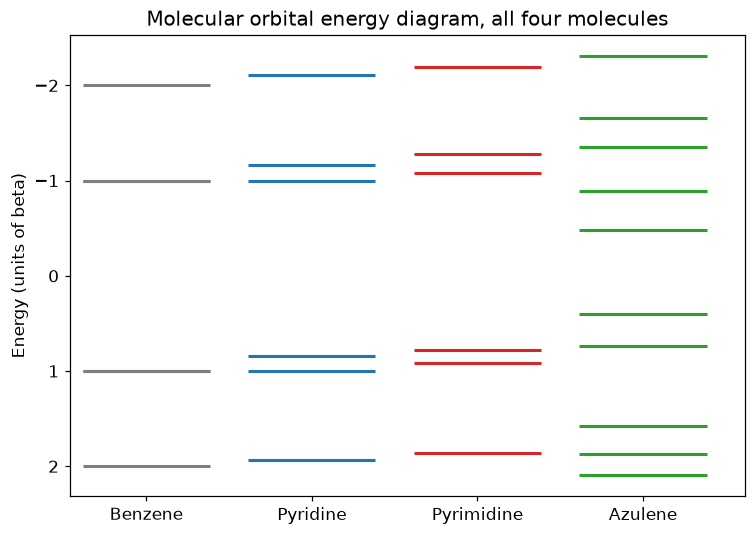

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

names = ["Benzene", "Pyridine", "Pyrimidine", "Azulene"]
energy_sets = [energies_benzene, energies_pyridine, energies_pyrimidine, energies_azulene]
colors = ["tab:gray", "tab:blue", "tab:red", "tab:green"]

for i, (name, energies, color) in enumerate(zip(names, energy_sets, colors)):
    x_start = i * 0.26 + 0.02
    ax.hlines(energies, xmin=x_start, xmax=x_start + 0.2, color=color, linewidth=2)

ax.set_xlim(0, 1.06)
ax.set_xticks([0.12, 0.38, 0.64, 0.90], names)
ax.set_ylabel("Energy (units of beta)")
ax.set_title("Molecular orbital energy diagram, all four molecules")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Reading this table and diagram together tells a clean, coherent story. Starting from benzene, adding heteroatoms (pyridine, then pyrimidine) shifts individual diagonal entries and breaks the ring's symmetry, spreading the orbital energies apart. Changing the topology entirely (azulene) does something related but distinct, it removes the source of degeneracy without touching a single atom type. Both routes modify the Hamiltonian, and both routes change the resulting electronic structure, but they do it through different terms in the matrix.

## Section 12: Explore your own molecules

By now you have seen every piece of the pipeline applied by hand, several times over. Let's wrap it all into one convenient function that takes any SMILES string and gives you the full picture: the molecule drawing, the adjacency matrix, the Hamiltonian, the eigenvalues, and an orbital energy plot.

This is the same idea as `Hückel_from_smiles` from Section 5, just extended to also handle the visualization side, so you have one function you can point at any aromatic molecule you're curious about.

In [22]:
def analyze_Hückel(smiles, heteroatom_shifts=None, name=None):
    """
    Run the full Hückel pipeline on a molecule and display the results.

    Parameters
    ----------
    smiles : str
        SMILES string of the molecule to analyze.
    heteroatom_shifts : dict, optional
        Maps atom index -> h_X value for any heteroatoms.
    name : str, optional
        A label for the molecule, used in plot titles. Defaults to the SMILES string.
    """
    if name is None:
        name = smiles

    H, mol, adjacency = Hückel_from_smiles(smiles, heteroatom_shifts=heteroatom_shifts)
    energies, coeffs = np.linalg.eigh(H)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Molecule drawing
    AllChem.Compute2DCoords(mol)
    img = Draw.MolToImage(mol, size=(300, 300))
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(name)

    # Adjacency matrix heatmap
    axes[1].imshow(adjacency, cmap="Greys")
    axes[1].set_title("Adjacency matrix")
    axes[1].set_xlabel("Atom index")
    axes[1].set_ylabel("Atom index")

    # Orbital energy levels
    axes[2].hlines(energies, xmin=0.3, xmax=0.7, color="black", linewidth=2)
    axes[2].set_xlim(0, 1)
    axes[2].set_xticks([])
    axes[2].set_ylabel("Energy (units of beta)")
    axes[2].set_title("Orbital energies")
    axes[2].invert_yaxis()

    plt.tight_layout()
    plt.show()

    print(f"{name}: {mol.GetNumAtoms()} atoms")
    print("Orbital energies (units of beta):", np.round(energies, 3))

    return H, energies, coeffs

Let's try it on a few molecules we have not looked at yet. Naphthalene is a plain hydrocarbon, two fused benzene rings, while furan and thiophene bring in oxygen and sulfur, heteroatoms with their own tabulated $h_X$ values (roughly 2.0 for furan oxygen and 1.5 for thiophene sulfur, reflecting how strongly each element pulls on the shared electron density in these five membered aromatic rings).

In [ ]:
# Naphthalene: two fused benzene rings, no heteroatoms
_ = analyze_Hückel("c1ccc2ccccc2c1", name="Naphthalene")

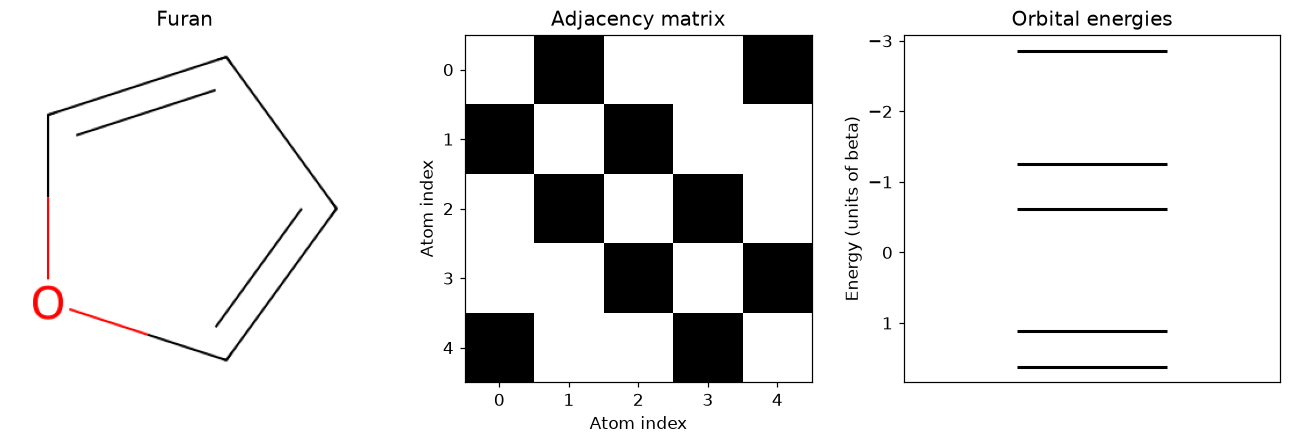

Furan: 5 atoms
Orbital energies (units of beta): [-2.861 -1.254 -0.618  1.115  1.618]


In [23]:
# Furan: a five-membered aromatic ring with one oxygen
furan_smiles = "c1ccoc1"
mol_furan_probe = Chem.MolFromSmiles(furan_smiles)
oxygen_index = [atom.GetIdx() for atom in mol_furan_probe.GetAtoms()
                if atom.GetSymbol() == "O"][0]

_ = analyze_Hückel(furan_smiles, heteroatom_shifts={oxygen_index: 2.0}, name="Furan")

**Try it yourself:** Pick a molecule you are curious about (something from a class you took, a drug molecule, whatever comes to mind) and look up or write out its SMILES string. Run it through `analyze_Hückel`. If it contains a heteroatom, look up an appropriate $h_X$ value (a quick search for "Hückel parameters heteroatom table" will turn up several reference tables) and pass it in. Does the resulting orbital diagram match your chemical intuition about that molecule?

## Key takeaways

We covered a lot of ground, but it all traces back to one repeated idea. Let's pull it apart one more time:

- Molecular structure becomes a graph, atoms become nodes, bonds become edges.
- The graph becomes a Hamiltonian, diagonal entries hold each atom's baseline energy (alpha), off diagonal entries hold the interaction strength between bonded atoms (beta).
- The Hamiltonian becomes an eigenvalue problem, one that NumPy can solve for us directly because the matrix is real and symmetric.
- Eigenvalues determine molecular orbital energies, sorted from most stable to least stable.
- Eigenvectors determine how electron density is distributed across the atoms in each orbital.
- Changing atom types (carbon to nitrogen, oxygen, sulfur) modifies the Hamiltonian's diagonal, and shifts energies accordingly.
- Changing graph topology (which atoms are bonded to which) modifies the Hamiltonian's off diagonal entries, and reshapes the whole spectrum, even when every atom stays the same element.

Everything in this notebook follows from the same mathematical idea: represent a molecule as a matrix, then let linear algebra reveal its electronic structure.

If you found this useful, the natural next step in the Bonds & Nodes curriculum is to ask what happens when, instead of hand picking alpha and beta from a lookup table, we let a neural network learn what those values should be directly from data. That question is where Hückel theory quietly turns into the starting point for modern graph neural networks in molecular machine learning, which is exactly where this series is headed next.